# Overview

Simple demo with flu model with "toy" (not necessarily realistic or finalized) parameters

We go over
- How to set up subpopulation models and metapopulation models.
- How to run accept-reject algorithm.
- How to run experiments to organize output of multiple replications. 

# Imports

In [2]:
# Misc: suppress SSE4.2 deprecation warnings
# This is not an error, just a warning about future hardware compatibility (not relevant in general)
import os
os.environ["MKL_DEBUG_CPU_TYPE"] = "5" 

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import city-level transmission base components module
import clt_toolkit as clt
from clt_toolkit.utils import daily_sum_over_timesteps

# Import flu model module, which contains customized subclasses
import flu_core as flu

# Import immunity module, which contains some nice graphing functions
#import toy_immunity_core as imm

import json

# from flu_instances.examples import flu_example_utils_Calib as flu_utils
from flu_instances.examples import flu_example_utils as flu_utils

# Reading Input Files

In [3]:
# Use the same calibrated Austin L2 deterministic baseline as flu_scenario_analysis.py.
inputs = flu_utils.load_calibrated_austin_inputs(
    clt,
    flu,
    pd,
    season="2024_2025",
    region_model="L2",
    calibration_mode="pop",
    flatten_contact_calendar=False,
)

params_by_subpop = inputs["params_by_subpop"]
params = params_by_subpop["east"]
mixing_params = inputs["mixing_params"]
settings = clt.updated_dataclass(
    inputs["settings_base"],
    {
        "transition_type": "binom_deterministic_no_round",
        "use_deterministic_softplus": False,
    },
)
calibrated_offset = int(inputs["calibrated_offset"])
pop_scale = float(inputs["pop_scale"])
output_scale = pop_scale
full_season_days = len(inputs["calendar_df"]["east"])
scenario_aligned_run_days = full_season_days - calibrated_offset
full_season_dates = pd.date_range(start=str(settings.start_real_date), periods=full_season_days, freq="D")
rngs = flu_utils.make_rng_generators(88888, flu_utils.SUBPOP_CONFIG, np)

# Creating Subpopulation Models

In [4]:
# Build the same deterministic baseline as flu_scenario_analysis.py, including
# the calibrated E0 values and the deterministic population scaling used there.
import copy

scaled_states = {name: copy.deepcopy(state) for name, state in inputs["states"].items()}
for state in scaled_states.values():
    for comp_name in ["S", "E", "IP", "ISR", "ISH", "IA", "HR", "HD", "R", "D"]:
        setattr(state, comp_name, np.asarray(getattr(state, comp_name), dtype=float) * pop_scale)

build_inputs = {**inputs, "states": scaled_states}
flu_demo_model = flu_utils.build_flu_metapop_model(
    flu_utils.SUBPOP_CONFIG,
    build_inputs,
    params_by_subpop,
    settings,
    rngs,
    inputs["vaccines_df"],
    flu,
)
east = flu_demo_model.subpop_models["east"]
west = flu_demo_model.subpop_models["west"]

/Users/rfp437/Work/CityLevelTransmission/CLT_BaseModel/flu_core/flu_components.py:497: UserWarning: Vaccine immunity reset date is set as 07/30. 
Initial vaccine-induced immunity value is being adjusted by resetting immunity to 0 at that date, and by taking into account vaccines administered after this date, and before simulation start date.
  warnings.warn(msg)
/Users/rfp437/Work/CityLevelTransmission/CLT_BaseModel/flu_core/flu_components.py:497: UserWarning: Vaccine immunity reset date is set as 07/30. 
Initial vaccine-induced immunity value is being adjusted by resetting immunity to 0 at that date, and by taking into account vaccines administered after this date, and before simulation start date.
  warnings.warn(msg)


In [5]:
## Determine the total number of individuals in each subpopulation to compute per capita statistics
NumIndiv_east = np.sum(np.asarray(inputs["states"]["east"].S) + np.asarray(inputs["states"]["east"].E) + np.asarray(inputs["states"]["east"].IP) + np.asarray(inputs["states"]["east"].ISR) + np.asarray(inputs["states"]["east"].ISH) + np.asarray(inputs["states"]["east"].IA) + np.asarray(inputs["states"]["east"].HR) + np.asarray(inputs["states"]["east"].HD) + np.asarray(inputs["states"]["east"].R) + np.asarray(inputs["states"]["east"].D))
NumIndiv_west = np.sum(np.asarray(inputs["states"]["west"].S) + np.asarray(inputs["states"]["west"].E) + np.asarray(inputs["states"]["west"].IP) + np.asarray(inputs["states"]["west"].ISR) + np.asarray(inputs["states"]["west"].ISH) + np.asarray(inputs["states"]["west"].IA) + np.asarray(inputs["states"]["west"].HR) + np.asarray(inputs["states"]["west"].HD) + np.asarray(inputs["states"]["west"].R) + np.asarray(inputs["states"]["west"].D))
print (NumIndiv_east)
print (NumIndiv_west)

489273.0
677575.0


# Modifying Parameters

In [6]:
# These values now come from the same calibrated JSON used by flu_scenario_analysis.py.
print(east.params.beta_baseline)
print(west.params.beta_baseline)
print(calibrated_offset)
print(pop_scale)

0.033335137897779706
0.033335137897779706
65
100.0


In [7]:
# The calibrated IHRs and E0 are also loaded directly from that JSON.
print(east.params.IP_to_ISH_prop)
print(west.params.IP_to_ISH_prop)
print(inputs["states"]["east"].E)
print(inputs["states"]["west"].E)

[[0.00737294 0.05750895]
 [0.00146896 0.00470068]
 [0.00092404 0.00619109]
 [0.0026673  0.01920454]
 [0.00916994 0.04676668]]
[[0.00370017 0.02886132]
 [0.00114237 0.00365558]
 [0.00044791 0.00300101]
 [0.00082089 0.00591041]
 [0.00546054 0.02784877]]
[[1.92216101e-05 9.69156812e-07]
 [6.92341396e-06 8.64453261e-07]
 [1.32289912e-05 2.92362321e-06]
 [1.98734844e-05 1.07011070e-05]
 [1.17461845e-04 1.44729774e-04]]
[[1.91206571e-05 1.07011070e-06]
 [6.84553564e-06 9.42331982e-07]
 [1.31482289e-05 3.00438646e-06]
 [1.97511867e-05 1.08234057e-05]
 [1.18248430e-04 1.43943211e-04]]


# Create Metapopulation Model

In [8]:
# The calibrated metapopulation model was already assembled above.
flu_demo_model

# Simulation and Analysis

In [9]:
# Get the current real date of the simulation and the
#   current simulation day
print(flu_demo_model.current_simulation_day, flu_demo_model.current_real_date)

# Simulate the post-offset horizon so this notebook matches flu_scenario_analysis.py.
print(f"Using offset {calibrated_offset}, so a {full_season_days}-day full-season horizon corresponds to {scenario_aligned_run_days} simulated days.")
flu_demo_model.simulate_until_day(scenario_aligned_run_days)

# Get the current real date of the simulation and the
#   current simulation day
print(flu_demo_model.current_simulation_day, flu_demo_model.current_real_date)

0 2024-08-01
Using offset 65, so a 304-day full-season horizon corresponds to 239 simulated days.
239 2025-03-28


Daily admissions peak: 0.000 on 2025-05-20
Final cumulative hospitalizations: 0.003


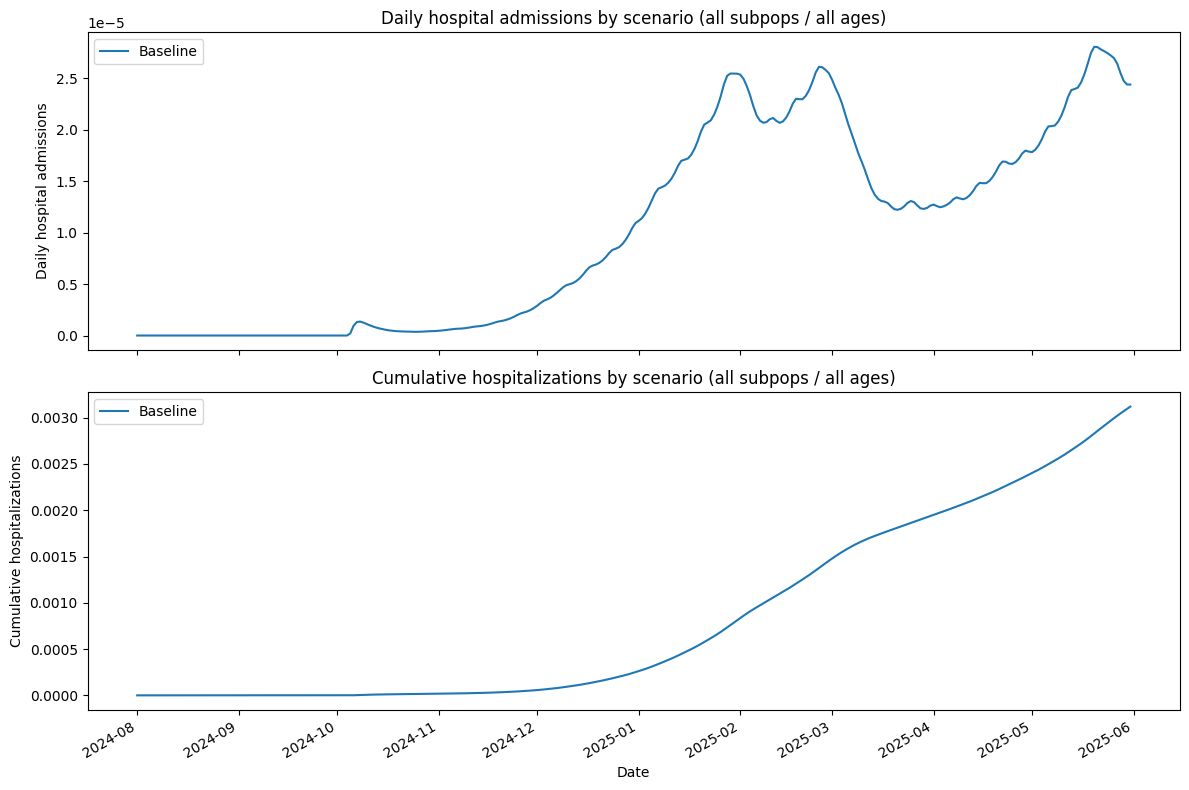

In [10]:
east_daily_hosp = daily_sum_over_timesteps(
    np.asarray(east.transition_variables.ISH_to_HR.history_vals_list) + np.asarray(east.transition_variables.ISH_to_HD.history_vals_list),
    east.simulation_settings.timesteps_per_day,
).sum(axis=(1, 2)) / output_scale
west_daily_hosp = daily_sum_over_timesteps(
    np.asarray(west.transition_variables.ISH_to_HR.history_vals_list) + np.asarray(west.transition_variables.ISH_to_HD.history_vals_list),
    west.simulation_settings.timesteps_per_day,
).sum(axis=(1, 2)) / output_scale
daily_hosp_all = east_daily_hosp + west_daily_hosp
daily_hosp_all_padded = np.concatenate([
    np.zeros((calibrated_offset,), dtype=float),
    daily_hosp_all,
])[:full_season_days]
cumulative_hosp_all_padded = np.cumsum(daily_hosp_all_padded)

print(f"Daily admissions peak: {daily_hosp_all_padded.max():.3f} on {full_season_dates[int(np.argmax(daily_hosp_all_padded))].date()}")
print(f"Final cumulative hospitalizations: {cumulative_hosp_all_padded[-1]:.3f}")

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axes[0].plot(full_season_dates, daily_hosp_all_padded, label="Baseline")
axes[0].set_title("Daily hospital admissions by scenario (all subpops / all ages)")
axes[0].set_ylabel("Daily hospital admissions")
axes[0].legend()

axes[1].plot(full_season_dates, cumulative_hosp_all_padded, label="Baseline")
axes[1].set_title("Cumulative hospitalizations by scenario (all subpops / all ages)")
axes[1].set_ylabel("Cumulative hospitalizations")
axes[1].set_xlabel("Date")
axes[1].legend()
fig.autofmt_xdate()
plt.tight_layout()

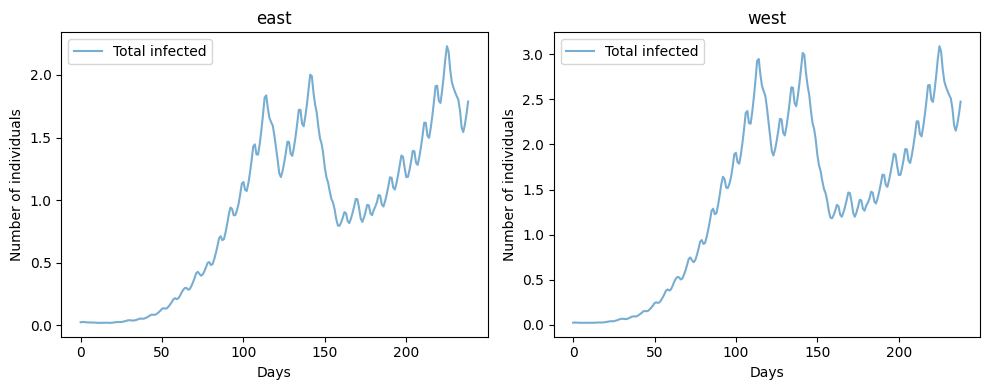

In [11]:
clt.plot_metapop_total_infected(flu_demo_model)


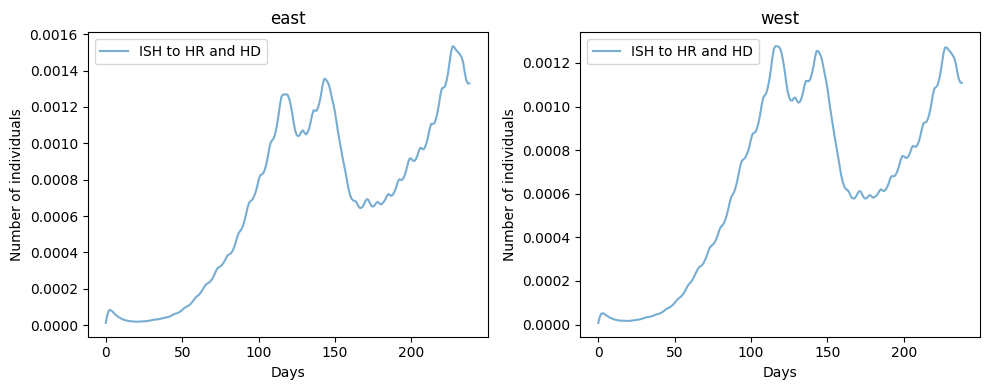

In [12]:
clt.plot_metapop_TransitionVariable(flu_demo_model)

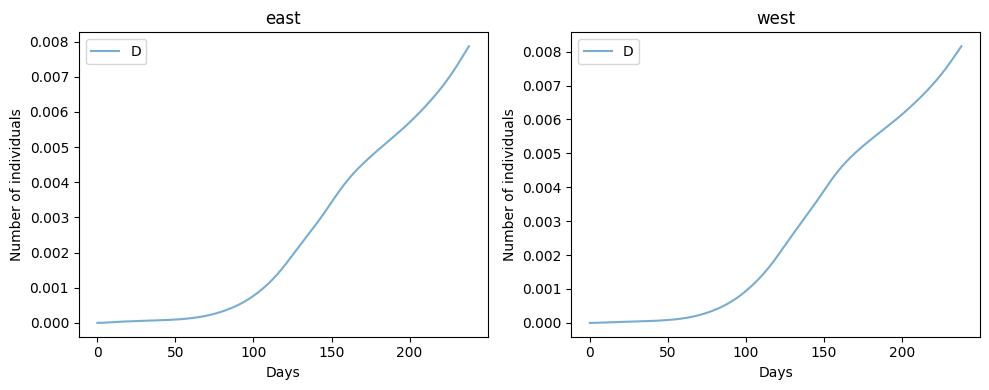

In [13]:
clt.plot_metapop_total_deaths(flu_demo_model)

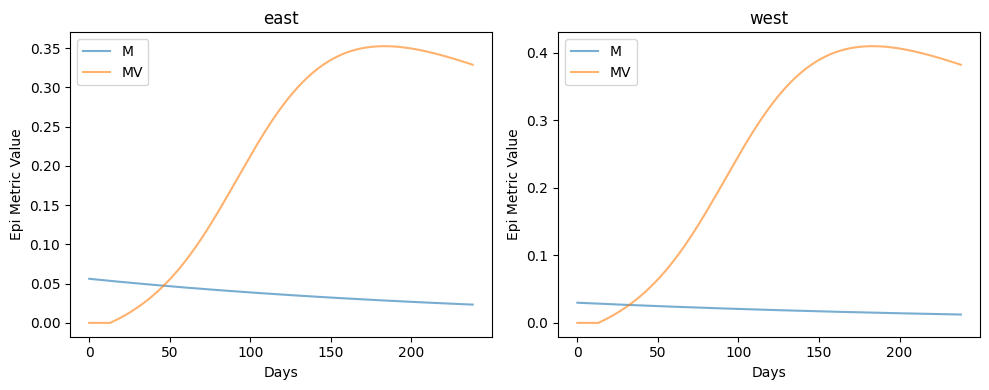

In [14]:
clt.plot_metapop_epi_metrics(flu_demo_model)

In [15]:
# Print the %population exposed for east and west Austin,
# knowing that some individuals are exposed twice since have R to S, many protected by immunity, but possibly not all
print(round(np.sum(np.asarray(east.transition_variables.S_to_E.history_vals_list))/output_scale/NumIndiv_east,3))
print(round(np.sum(np.asarray(west.transition_variables.S_to_E.history_vals_list))/output_scale/NumIndiv_west,3))

0.0
0.0


In [16]:
# Print the per capita number of hospitalizations for east and west Austin
east_IS_to_H = np.asarray(east.transition_variables.ISH_to_HR.history_vals_list) + \
    np.asarray(east.transition_variables.ISH_to_HD.history_vals_list)
west_IS_to_H = np.asarray(west.transition_variables.ISH_to_HR.history_vals_list) + \
    np.asarray(west.transition_variables.ISH_to_HD.history_vals_list)
eastHosp = round(np.sum(east_IS_to_H)/output_scale/NumIndiv_east*100000)
westHosp = round(np.sum(west_IS_to_H)/output_scale/NumIndiv_west*100000)
eastHosp = round(np.sum(east_IS_to_H)/output_scale)
westHosp = round(np.sum(west_IS_to_H)/output_scale)
print(eastHosp)
print(westHosp)
# Cumulative hospitalizations was 316 in East and 286 in West (65 and 42 per 100,000) for 2024-2025

0
0


In [17]:
# Timing of hospitalization peak, first for East
# First need to sum over all "H" compartments
hospit_compartment_names = [name for name in east.compartments.keys() if "H" in name]
hospit_compartments_history = [east.compartments[compartment_name].history_vals_list for compartment_name in hospit_compartment_names]
total_hospitE = np.sum(np.asarray(hospit_compartments_history), axis=(0, 2, 3))
print(np.argmax(total_hospitE))

# then for West
hospit_compartment_names = [name for name in west.compartments.keys() if "H" in name]
hospit_compartments_history = [west.compartments[compartment_name].history_vals_list for compartment_name in hospit_compartment_names]
total_hospitW = np.sum(np.asarray(hospit_compartments_history), axis=(0, 2, 3))
print(np.argmax(total_hospitW))

# Peak hospitalizations was 10 in East on 1/27/25 and 11 in West on 1/28/25

231
119


In [18]:
## Total number of deaths is the number at the end (so last element in the array [-1]), since no one leaves death compartment
## Then sum across all age groups
DeathsEast = np.sum(np.asarray(east.compartments.D.history_vals_list)[-1]) / output_scale/NumIndiv_east*100000
DeathsWest = np.sum(np.asarray(west.compartments.D.history_vals_list)[-1]) / output_scale/NumIndiv_west*100000
DeathsEast = np.sum(np.asarray(east.compartments.D.history_vals_list)[-1]) / output_scale
DeathsWest = np.sum(np.asarray(west.compartments.D.history_vals_list)[-1]) / output_scale
print(round(DeathsEast,0))
print(round(DeathsWest,0))

0.0
0.0


Printing Results to File

In [19]:
## Print to file the value of M over time in East and West -- changing all M to MV would do the same for MV
## First line sums across risk group, so end up with array that just varies over age and time
#M_West = np.sum(np.asarray(west.epi_metrics.M.history_vals_list), axis=(2))
#MV_West = np.sum(np.asarray(west.epi_metrics.MV.history_vals_list), axis=(2))
#np.savetxt('M.csv', M_West,'%1.3f',',')
#np.savetxt('MV.csv', MV_West,'%1.3f',',')

In [20]:
## Print to file number of infected over time across all age groups
#np.savetxt('I_E.csv', total_infectedE,'%1.3f',',')
#np.savetxt('I_W.csv', total_infectedW,'%1.3f',',')

In [21]:
## Print to file the total number of recovered in west and the number of transitions from R to S (could extend to get east also)
## First line sums across risk group, so end with time x age matrix.  Need a 2D array for np.savetxt
## to get total_RtoS, sum across age and risk group, so end up with array that just varies over time
#RecoveredW = np.sum(np.asarray(west.compartments.R.history_vals_list), axis=(2))
#total_RtoS = np.sum(np.asarray(west.transition_variables.R_to_S.history_vals_list), axis=(2))
#np.savetxt('numRtoS.csv', total_RtoS,'%1.3f',',')
#np.savetxt('Recovered_west.csv', RecoveredW, '%1.3f',',')

In [22]:
## Print to file the total number of exposed over time, this time preserving different age groups
## First line sums across risk group, so end with time x age matrix.  Need a 2D array for np.savetxt
#ExposedW = np.sum(np.asarray(west.transition_variables.S_to_E.history_vals_list), axis=(2))
#np.savetxt('Exposed.csv', ExposedW, '%1.0f', ',')

In [23]:
## Print to file the total number of deaths over time, this time preserving different age groups
## First line sums across risk group, so end with time x age matrix.  Need a 2D array for np.savetxt
#DeathsW = np.sum(np.asarray(west.compartments.D.history_vals_list), axis=(2))
#np.savetxt('Deaths.csv', DeathsW, '%1.0f', ',')

In [24]:
## Print to file the total number of susceptibles over time, this time preserving different age groups
## First line sums across risk group, so end with time x age matrix.  Need a 2D array for np.savetxt
#SusceptibleW = np.sum(np.asarray(west.compartments.S.history_vals_list), axis=(2))
#np.savetxt('Susceptible.csv', SusceptibleW, '%1.0f', ',')

In [25]:
## Print to file the total number of hospitalizations over time, this time preserving different age groups
## First line sums across risk group, so end with time x age matrix.  Need a 2D array for np.savetxt
#num_west1 = np.sum(np.asarray(west.transition_variables.ISH_to_HR.history_vals_list)/output_scale, axis=(2))
#num_west2 = np.sum(np.asarray(west.transition_variables.ISH_to_HD.history_vals_list)/output_scale, axis=(2))
#num_west = num_west1 + num_west2

#num_east1 = np.sum(np.asarray(west.transition_variables.ISH_to_HR.history_vals_list)/output_scale, axis=(2))
#num_east2 = np.sum(np.asarray(west.transition_variables.ISH_to_HD.history_vals_list)/output_scale, axis=(2))
#num_east = num_east1 + num_east2

#tot = num_west + num_east
#np.savetxt('ISH_to_H.csv', tot, '%1.3f', ',')